## Load data

In [1]:
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import utils_se as se

dir_files = "predictions"
save_dir  = f"./{dir_files}/Images/"
os.makedirs(save_dir, exist_ok=True)

true_activities = pd.read_csv('./datasets/Signature_DBs/Activities_Sig_matched_images.csv')
mut_prof        = pd.read_csv('./datasets/Signature_DBs/Mutational_profile_matched_images.csv')

# Performance evaluation on 5 Fold

In [ ]:
all_data = se.load_fold_predictions(dir_files)
all_data.head()

In [3]:
true_activities, pred_activities = se.split_true_pred(all_data)
pred_f_activities = pred_activities.copy()

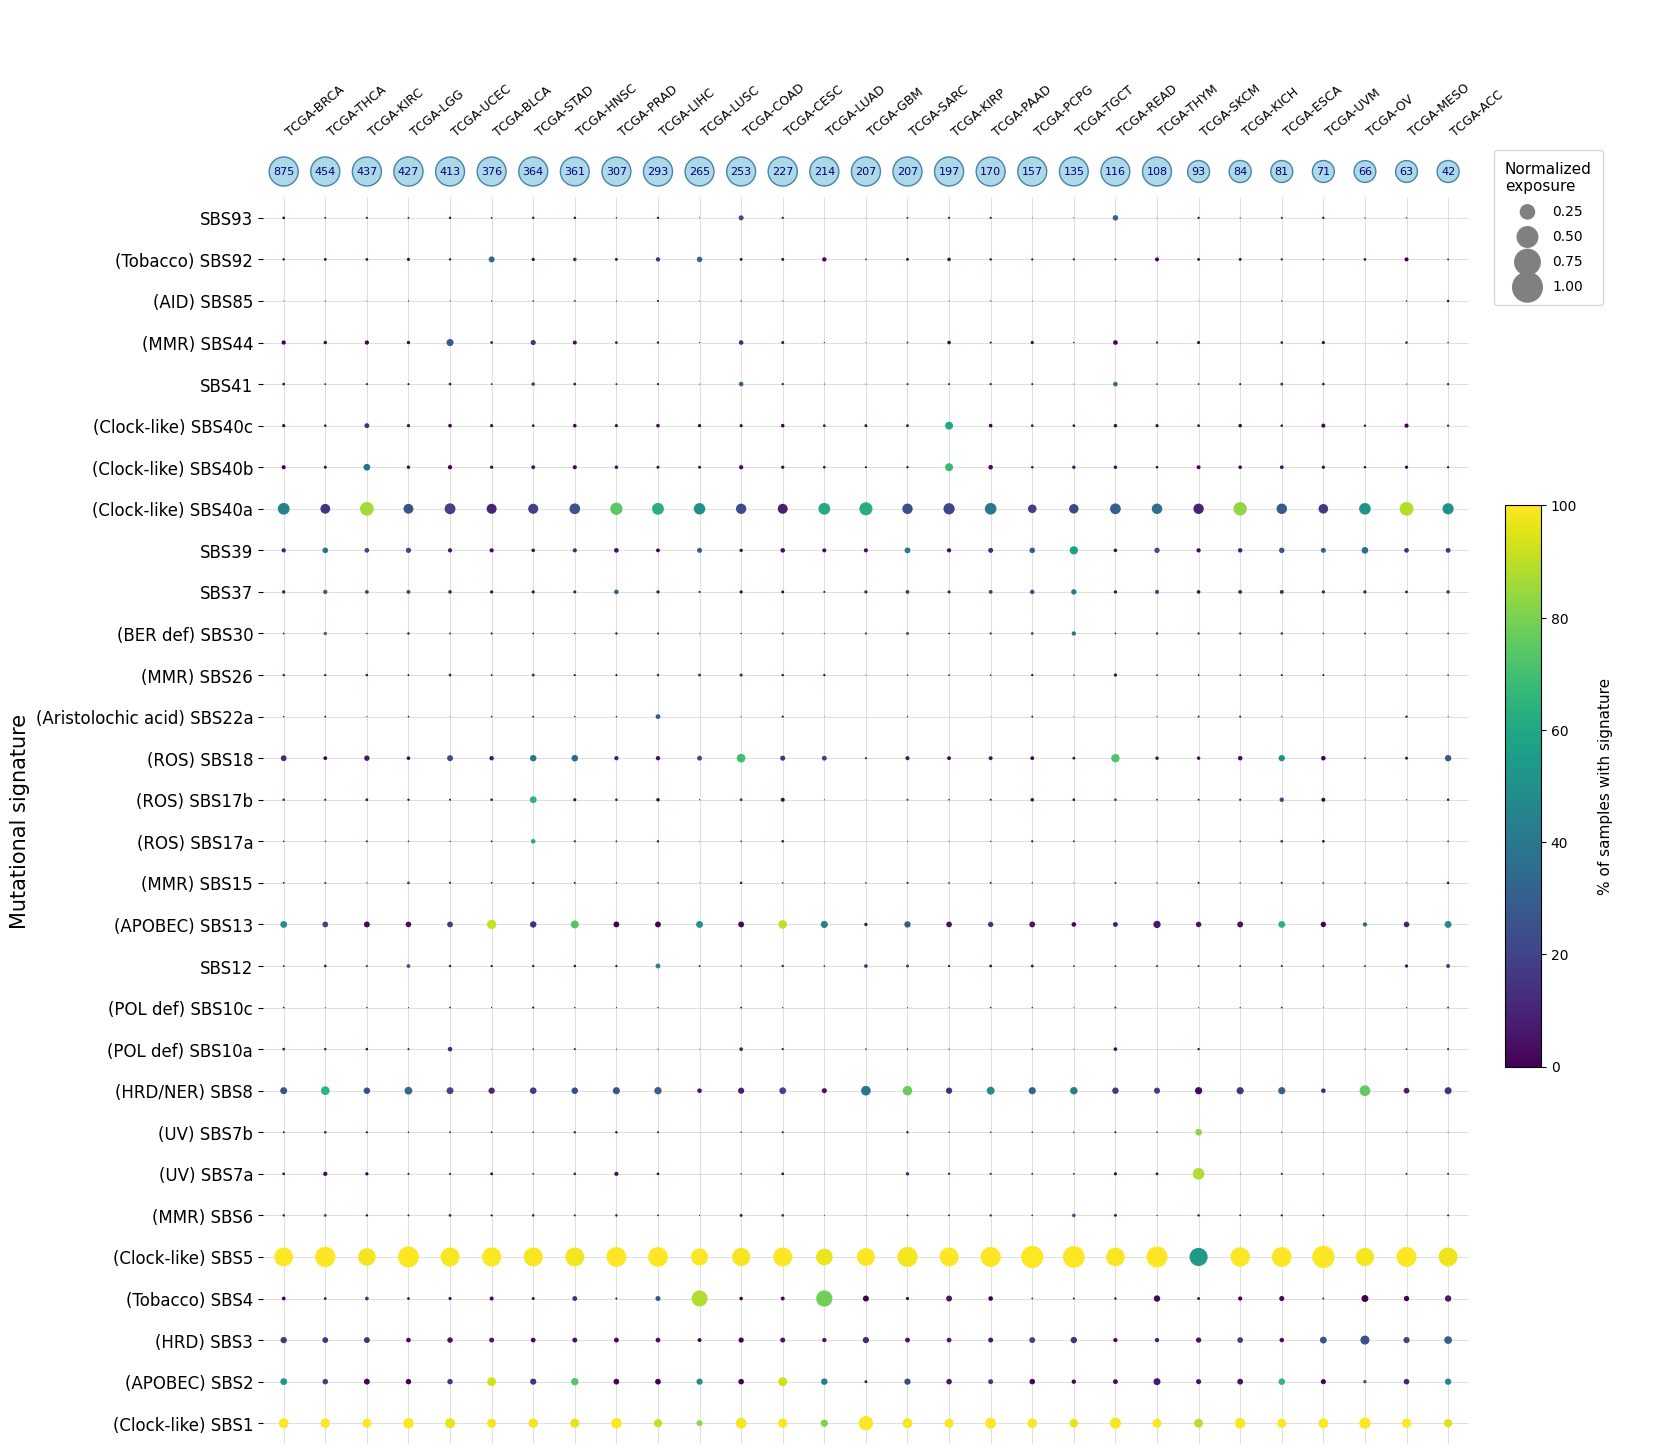

In [4]:
se.plot_bubble_tcga(true_activities)

# Cosine similarity for profiles

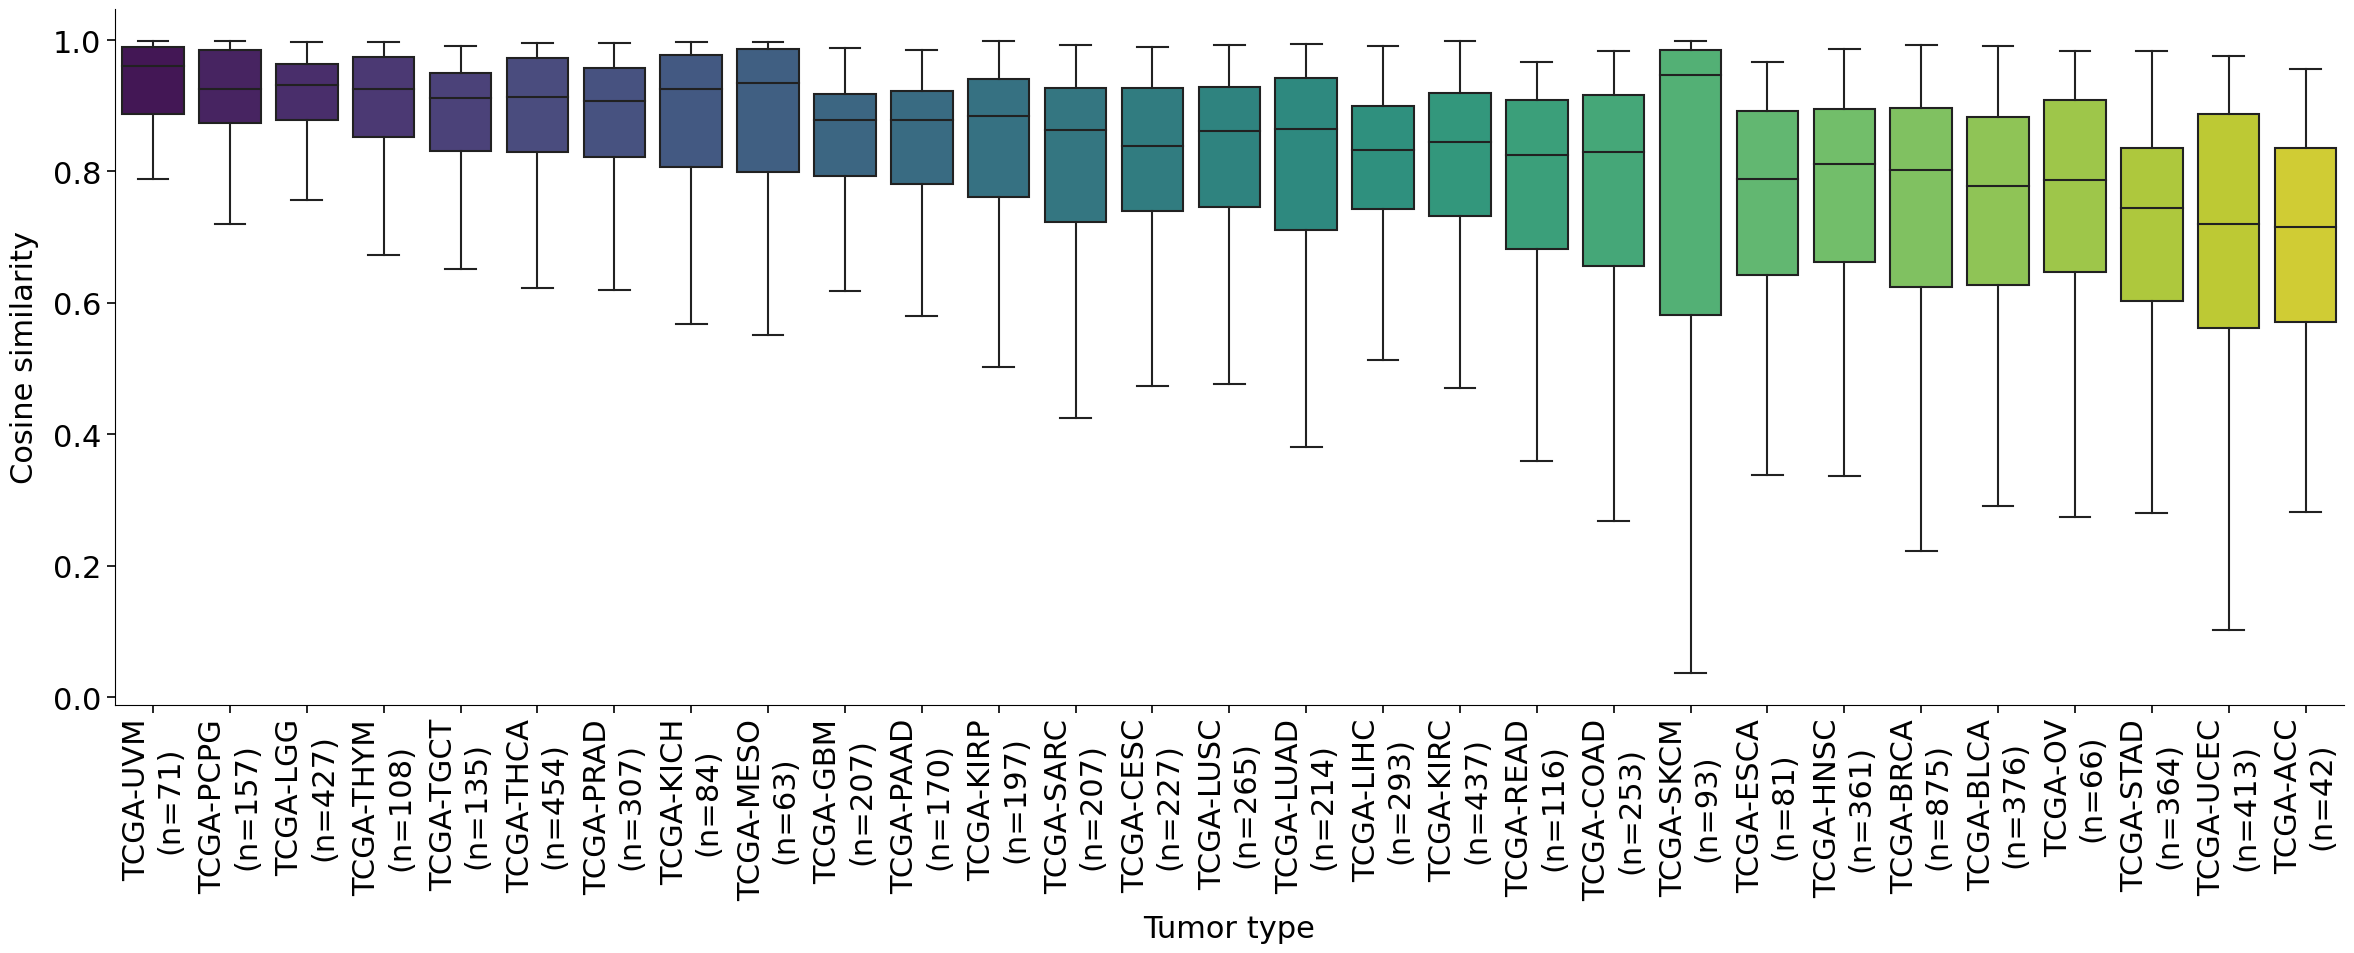

In [5]:
df1, df2, df_cos = se.plot_cosine_tcga(true_activities, pred_f_activities)

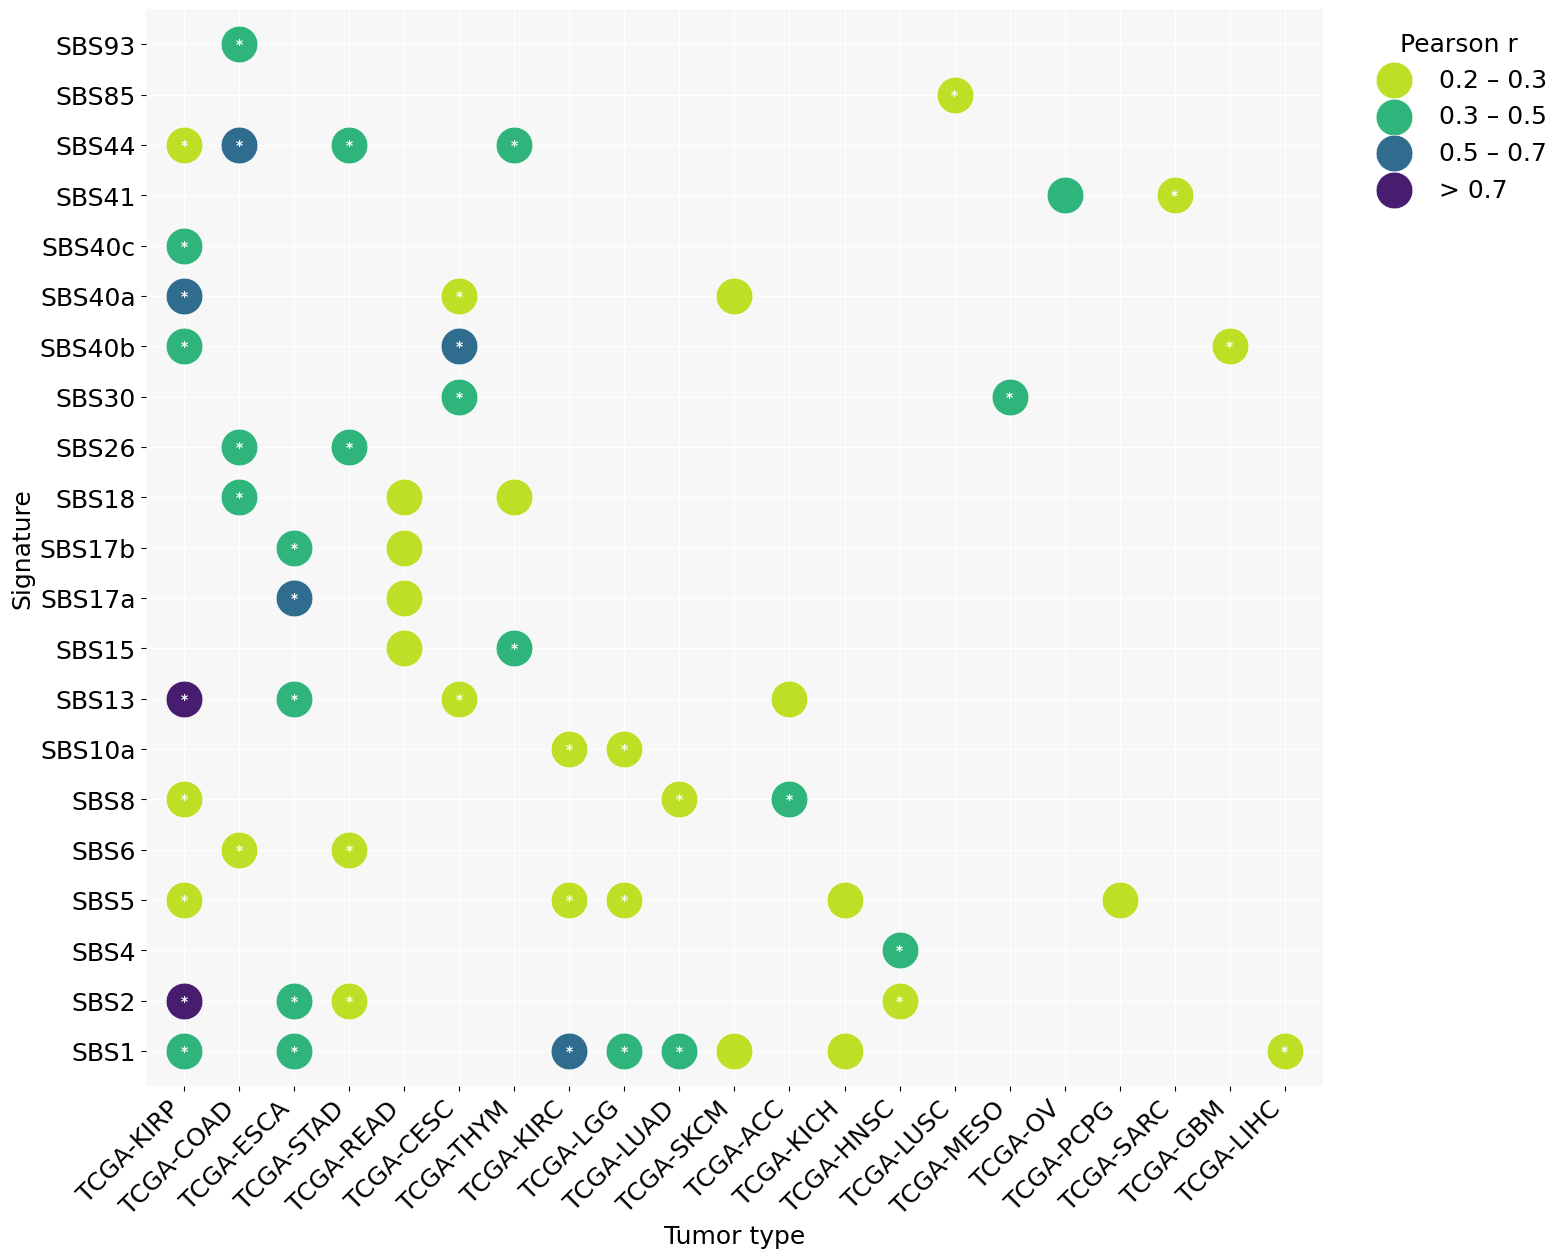

In [6]:
pearson_tcga = se.plot_pearson_bubble_tcga(true_activities, pred_f_activities)

In [7]:
df_true, df_pred, df_metrics, metrics_by_project = se.compute_top3_metrics(
    true_activities, pred_f_activities, df1)

# Comparison with a RF model trained on tumor types

In [8]:
rf = se.train_rf_tumor_types(dir_files)

df_final    = rf["df_final"]
y_cols      = rf["y_cols"]
encoder     = rf["encoder"]
final_model = rf["final_model"]

Processing fold 1...
Processing fold 2...
Processing fold 3...
Processing fold 4...
Processing fold 5...


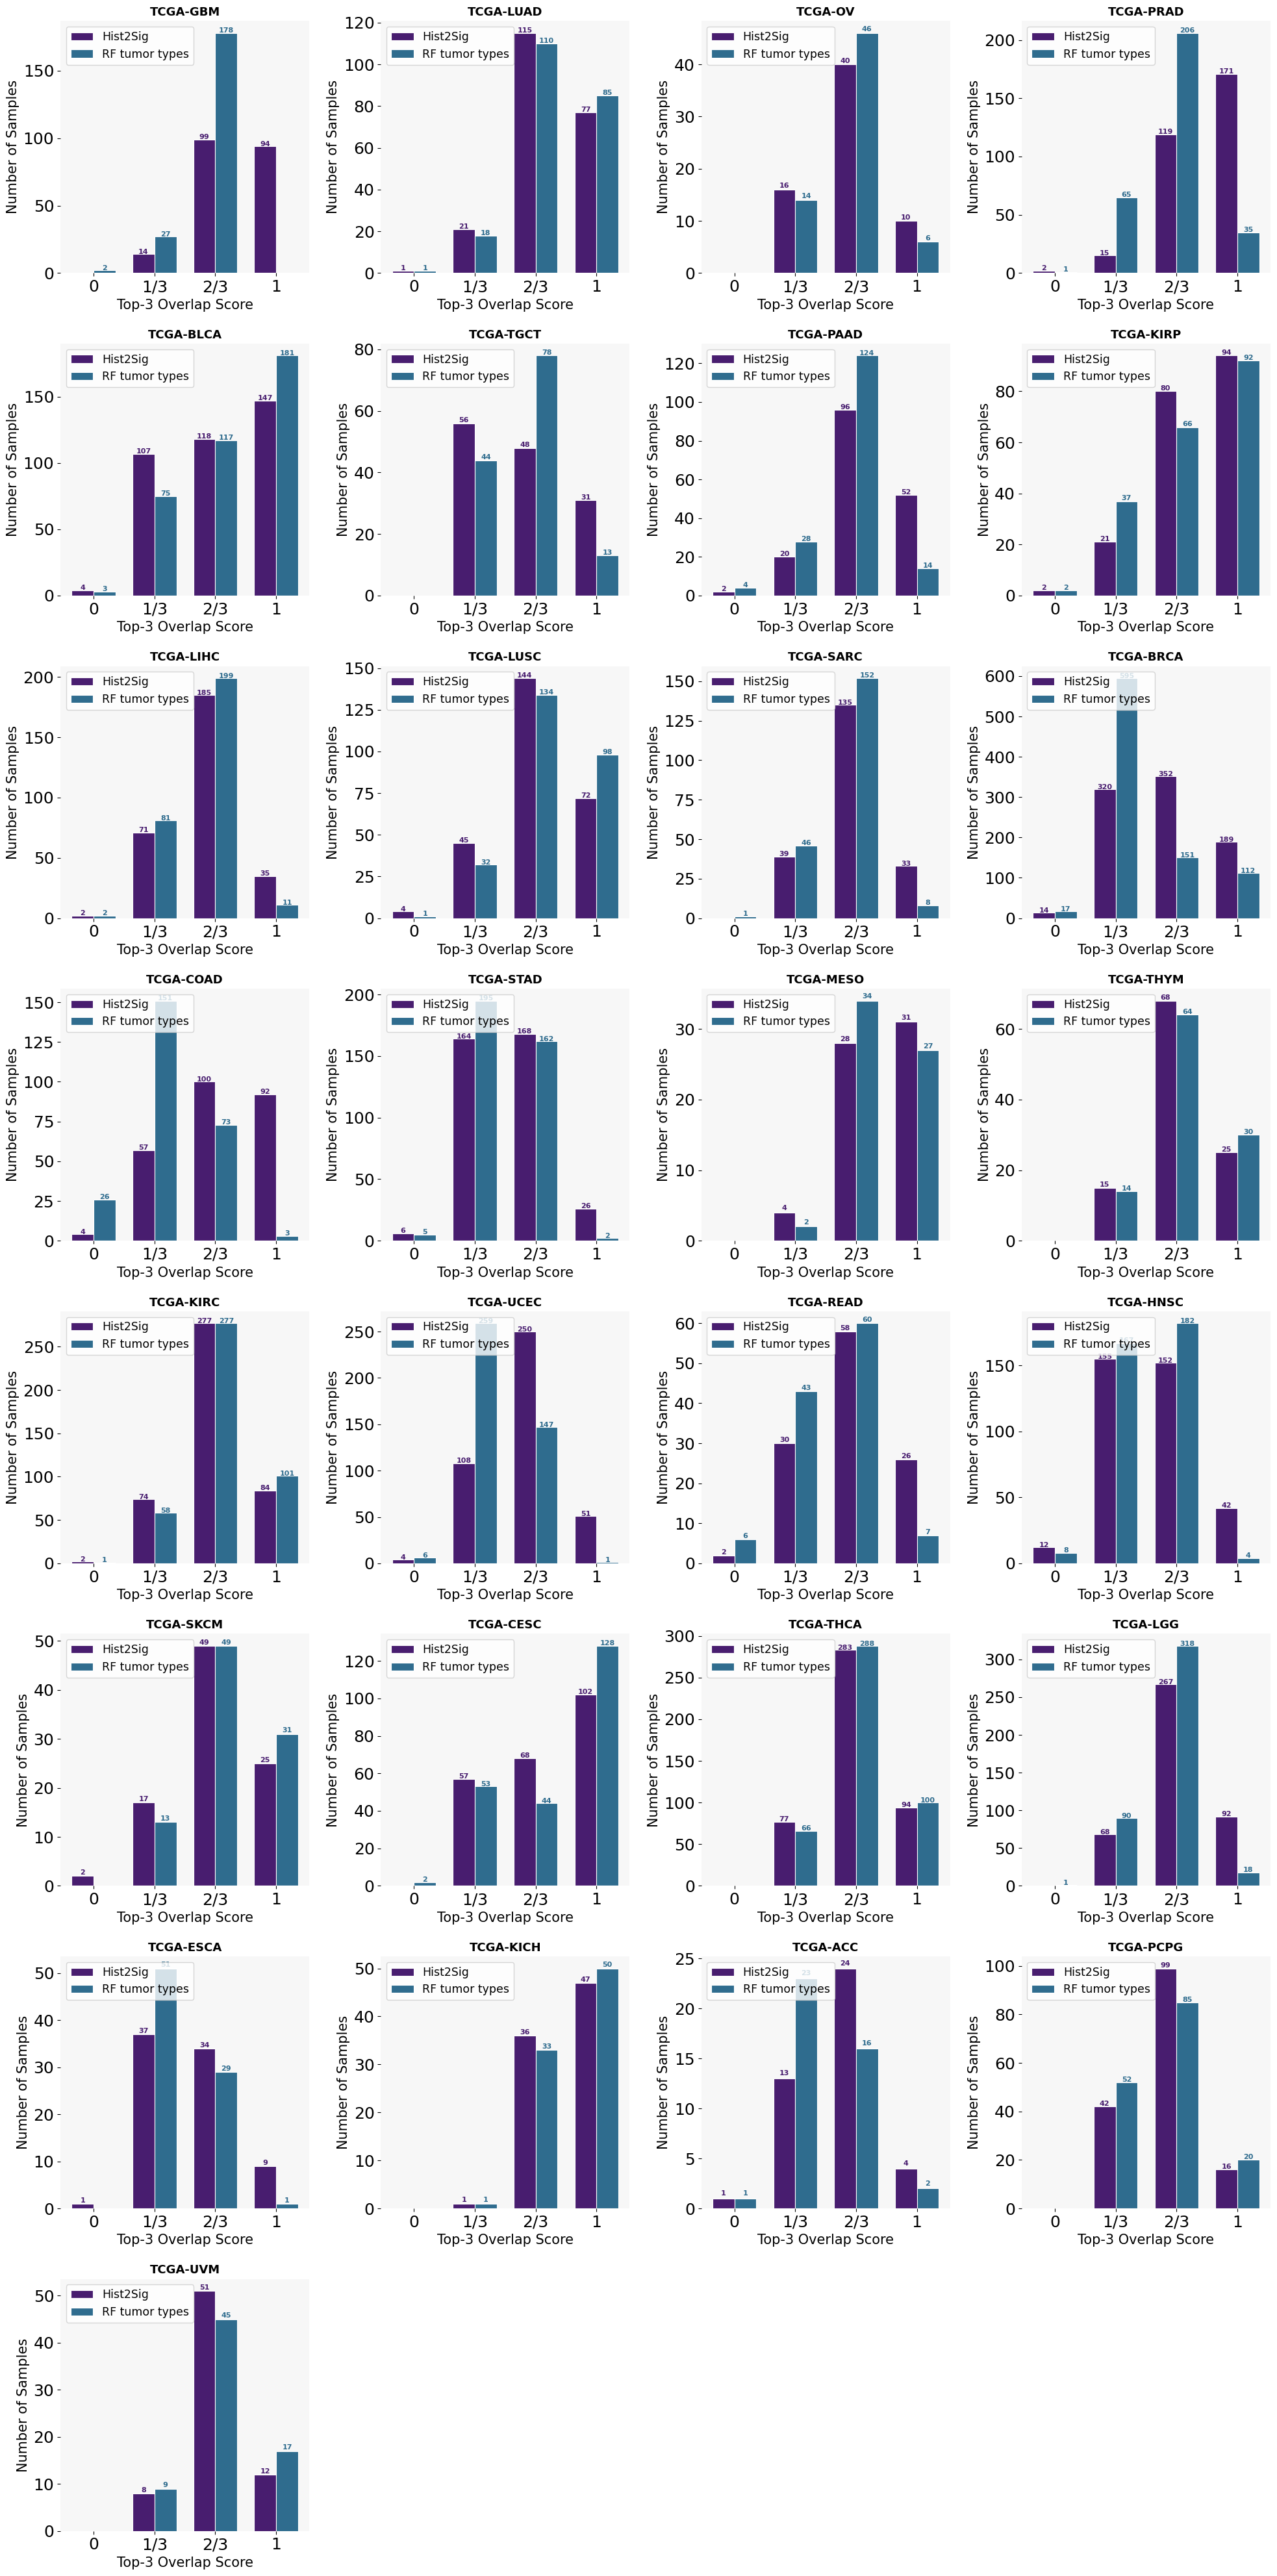

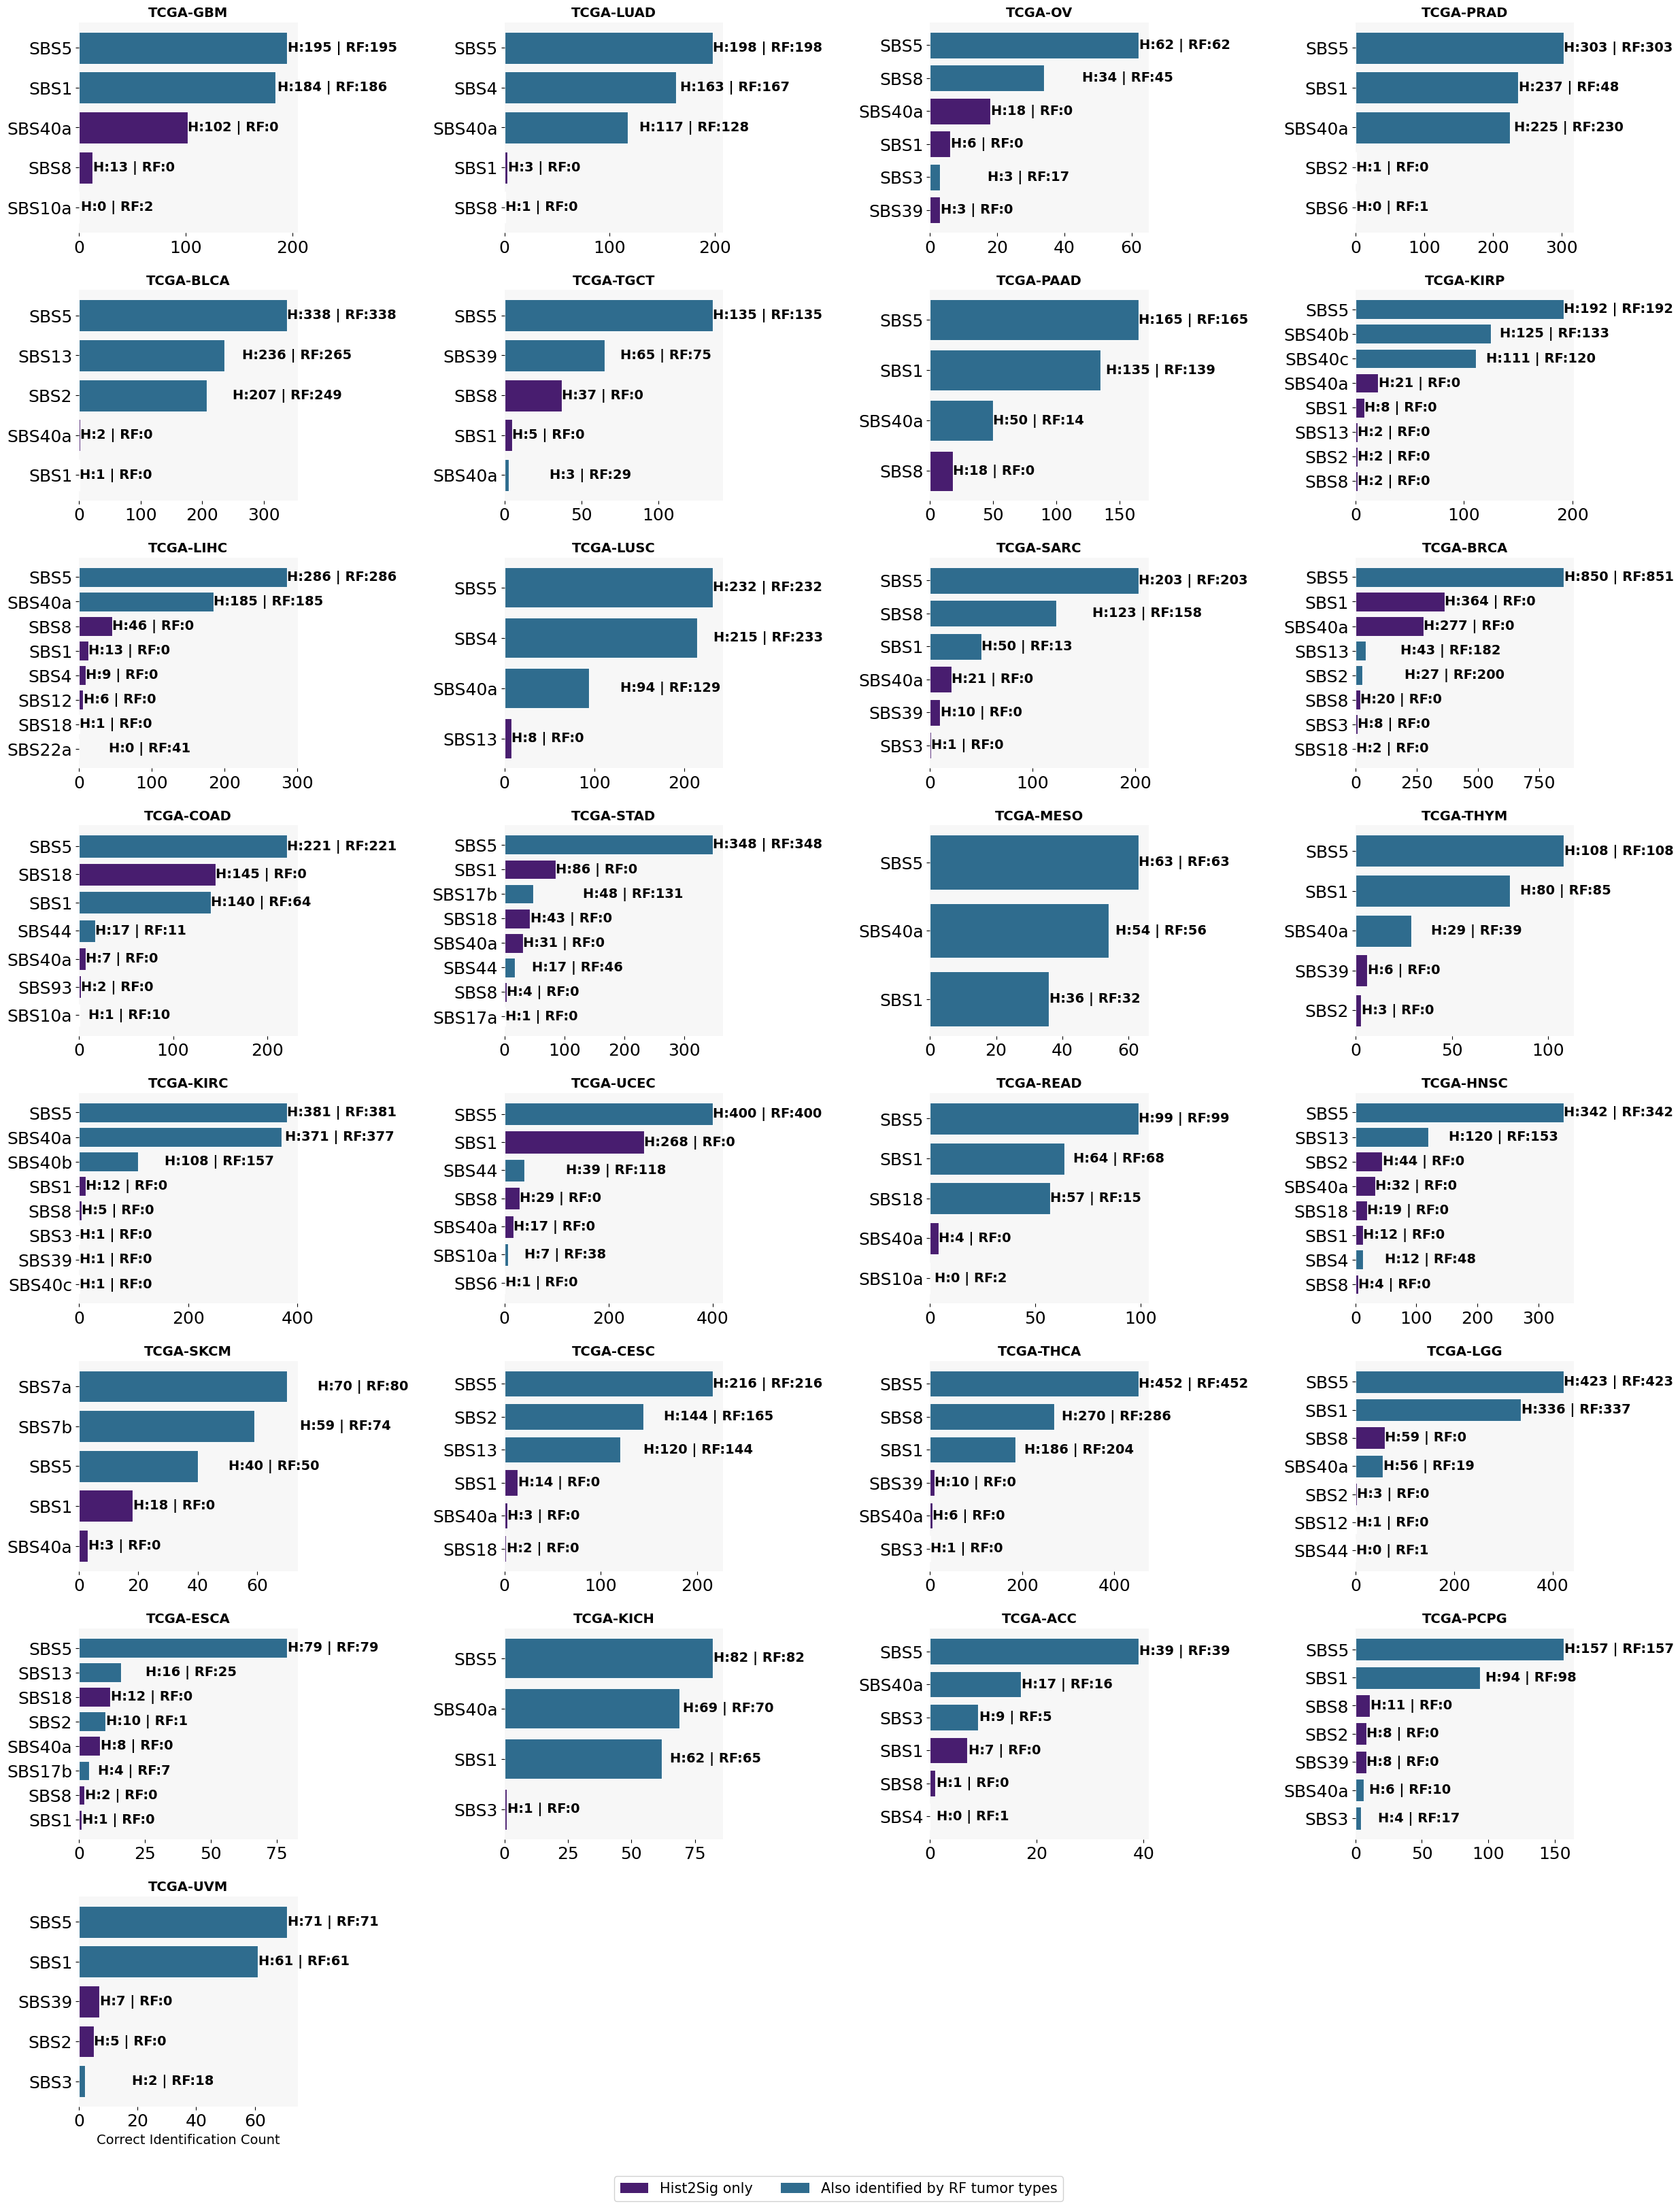

In [9]:
tcga = se.top3_figures_tcga(df_true, df_pred, df_final, df_metrics)

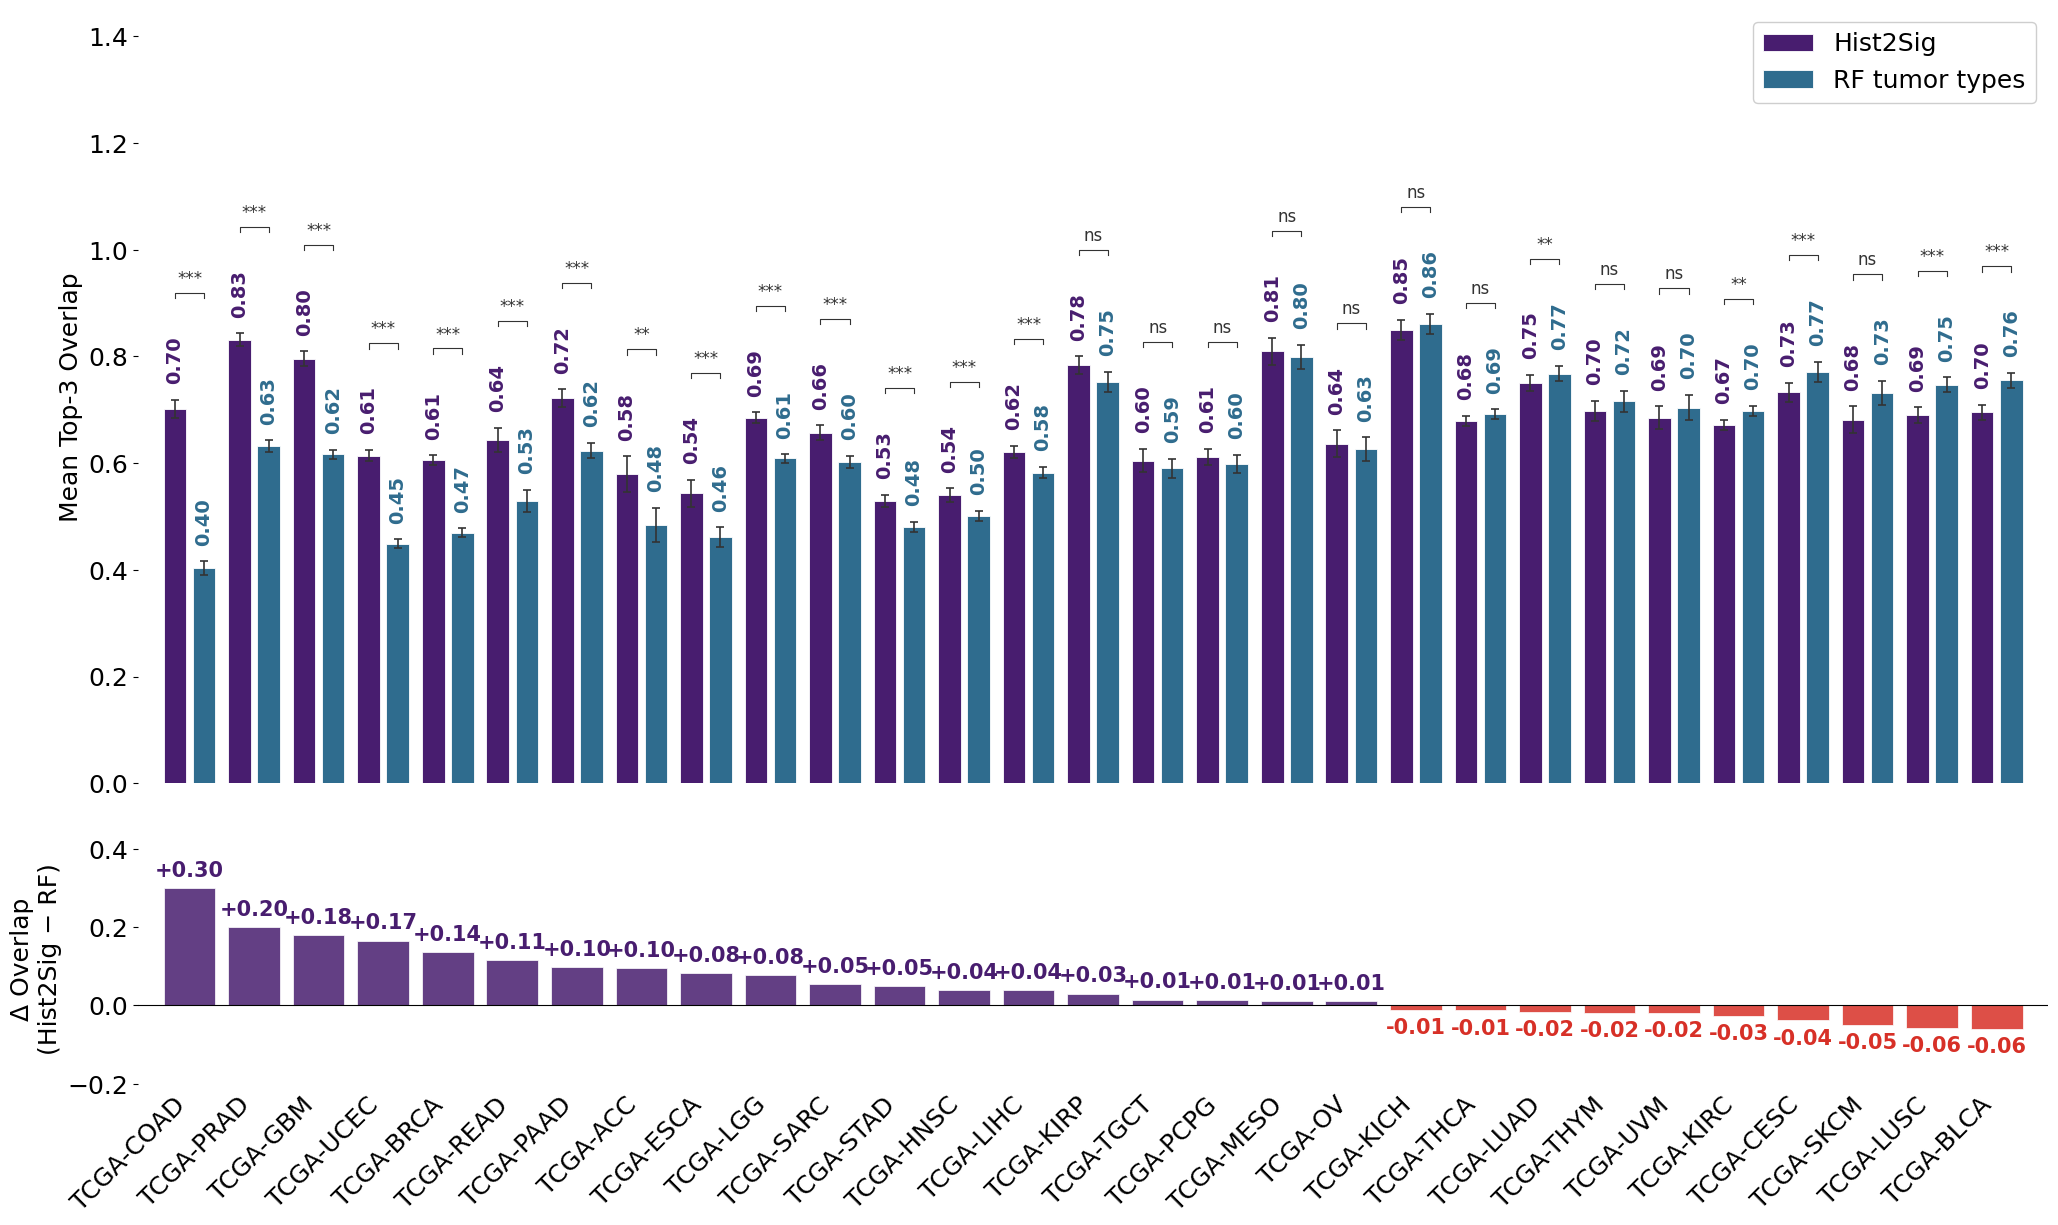

In [10]:
overlap_tcga = se.plot_mean_overlap_tcga(
    tcga["nn_true"], tcga["nn_pred"], tcga["rf_pred"],
    tcga["projects"], tcga["unique_projects"])

# CPTAC

In [11]:
cptac_data = se.build_cptac(dir_files)

true_activities_cptac     = cptac_data["true_activities_cptac"]
pred_cptac_median_eval    = cptac_data["pred_cptac_median_eval"]
true_activities_cptac_gat = cptac_data["true_activities_cptac_gat"]
pred_cptac_gat_eval       = cptac_data["pred_cptac_gat_eval"]

true_activities_cptac_gat['Primary Type'].value_counts()

Kidney               70
Bronchus and lung    52
Pancreas             38
Brain                33
Name: Primary Type, dtype: int64

In [12]:
proj_cptac, X_cptac, rf_pred_cptac = se.rf_predict_cptac(
    true_activities_cptac_gat, encoder, final_model, y_cols)

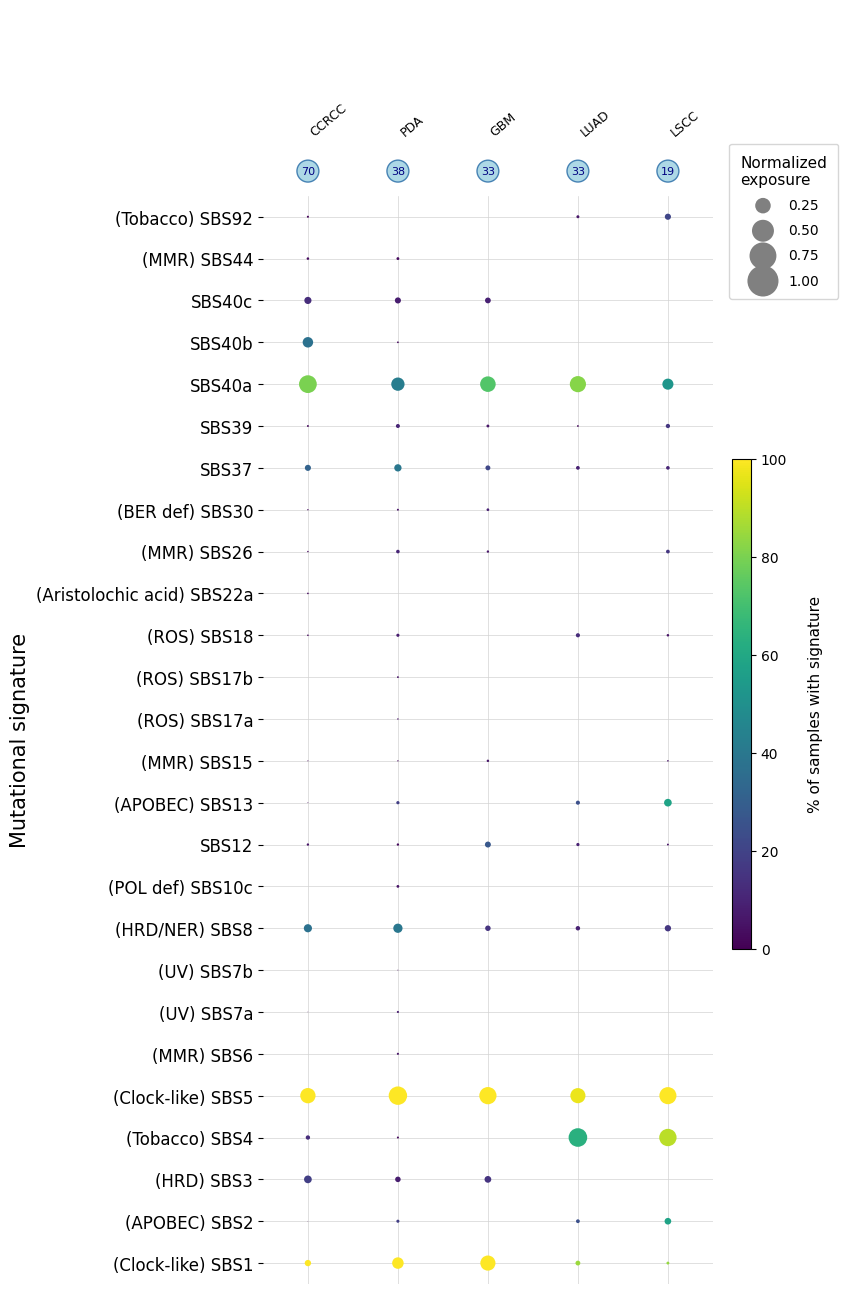

In [13]:
se.plot_bubble_cptac(true_activities_cptac_gat)

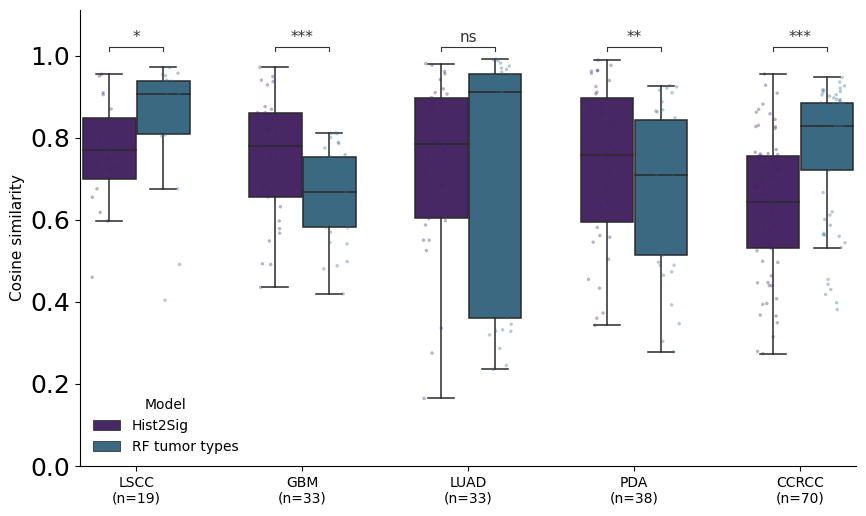


Wilcoxon signed-rank test (Hist2Sig vs RF, paired per patient):
  LSCC    p=0.0494  *
  GBM     p=0.0000  ***
  LUAD    p=0.6088  ns
  PDA     p=0.0043  **
  CCRCC   p=0.0000  ***


In [14]:
cos_cptac, cos_stats = se.plot_cosine_cptac_with_rf(
    true_activities_cptac_gat, pred_cptac_gat_eval, rf_pred_cptac)

## TCGA vs CPTAC cohort comparison

=== 1. TMB comparison ===
Project ID  n_TCGA  n_CPTAC  median_TCGA  median_CPTAC       U      p_value
  TCGA-GBM     207       33       8034.0        6154.0  5024.5 1.407328e-05
 TCGA-LUAD     214       33      44110.5       13819.0  5309.0 3.275233e-06
 TCGA-LUSC     265       19      43486.0       22530.0  4157.0 2.140746e-06
 TCGA-KIRC     437       70       6208.0        4368.5 22627.5 1.170938e-10
 TCGA-PAAD     170       38       5600.0        2959.0  4843.0 1.529798e-06

=== 2. Signature composition ===

Cosine similarity between mean profiles (TCGA vs CPTAC):
Project ID  cosine_similarity
  TCGA-GBM           0.977924
 TCGA-LUAD           0.964980
 TCGA-LUSC           0.990751
 TCGA-KIRC           0.991584
 TCGA-PAAD           0.984642


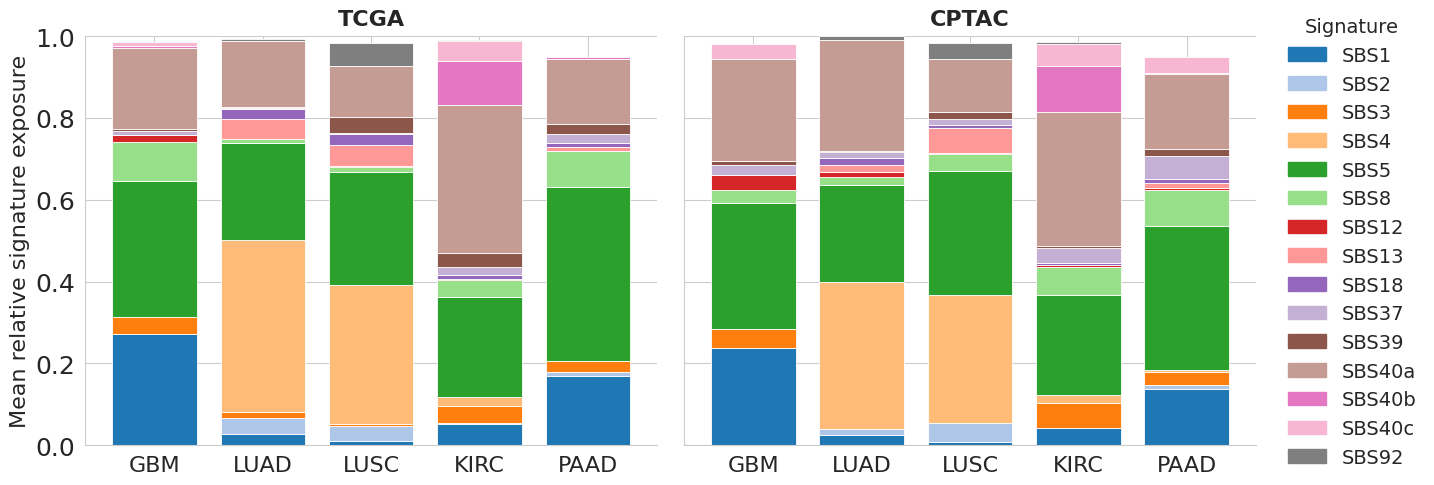

In [15]:
tcga_anal = true_activities.iloc[:, 5:]
sig_cols  = [c for c in tcga_anal.columns if c.startswith('SBS')]

cptac_gat_anal = true_activities_cptac_gat.iloc[:, 9:-1].reindex(columns=sig_cols)
cptac_gat_anal.insert(0, 'Project ID', proj_cptac)

assert not cptac_gat_anal[sig_cols].isna().any().any(), \
    cptac_gat_anal[sig_cols].columns[cptac_gat_anal[sig_cols].isna().any()].tolist()

results = se.run_cohort_comparison(tcga_anal, cptac_gat_anal, save_dir)

=== TMB observed vs predicted ===


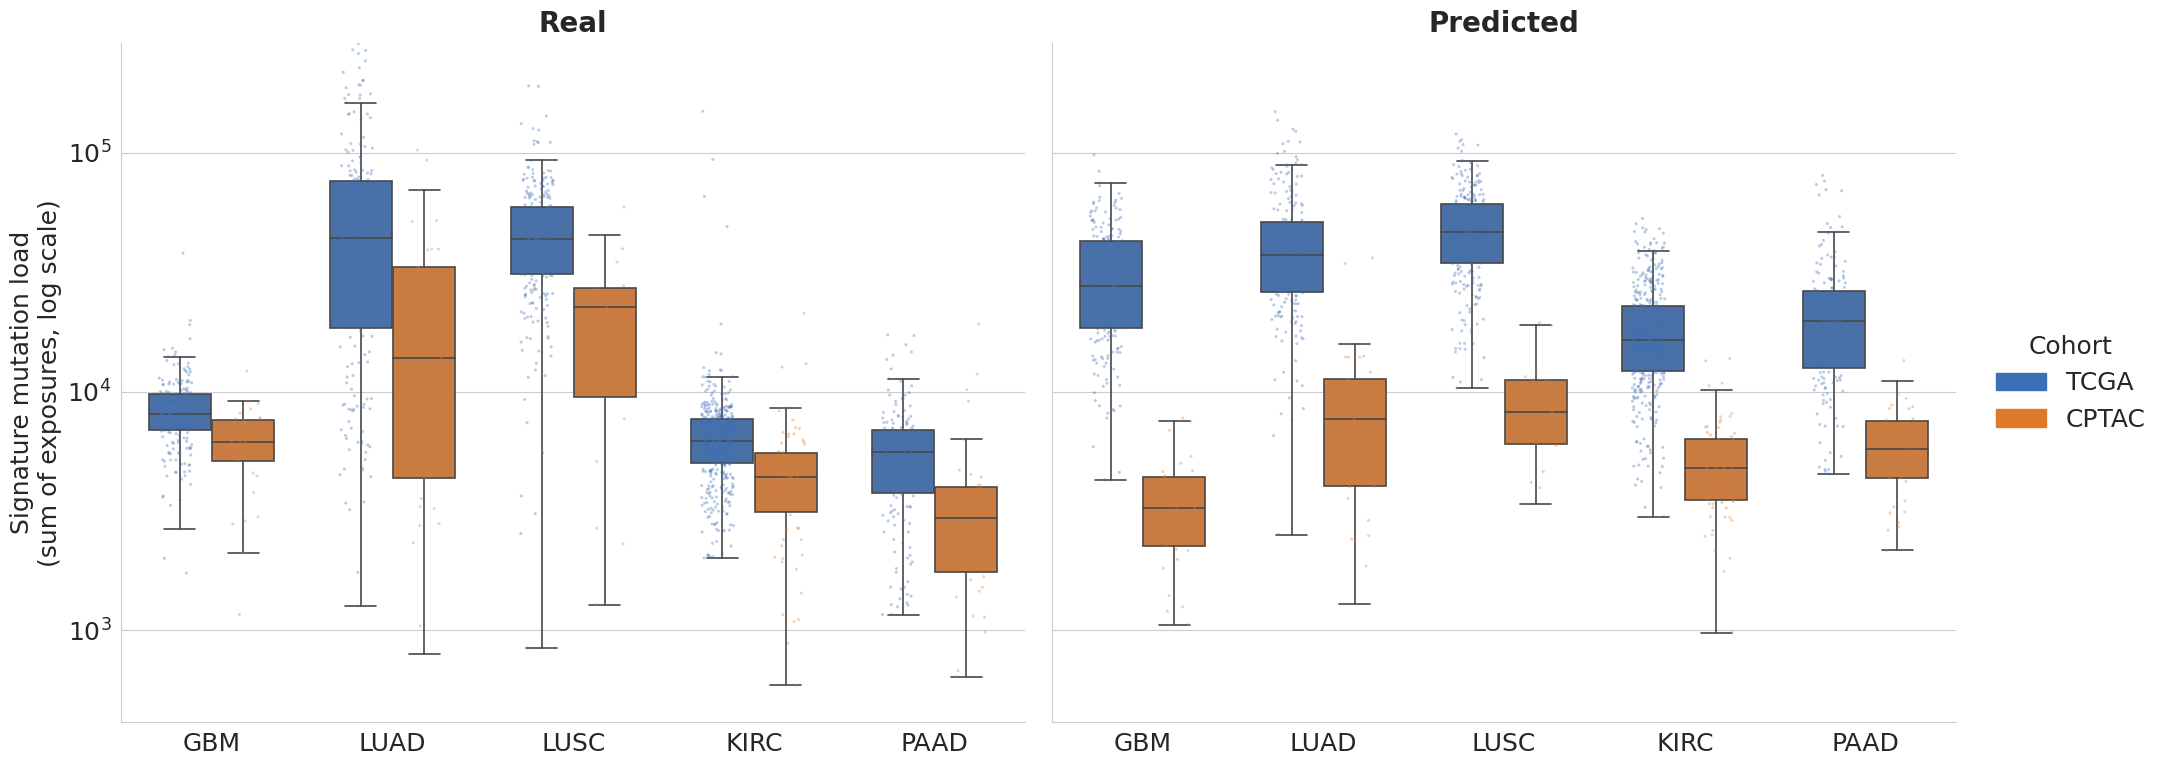

In [16]:
pred_tcga_anal = pred_f_activities.iloc[:, 6:][df1.columns].copy()
pred_tcga_anal['Project ID'] = true_activities['Project ID']

pred_cptac_anal = pred_cptac_median_eval.iloc[:, :-1].copy()
pred_cptac_anal['Project ID'] = cptac_gat_anal['Project ID']

tmb_summary = se.run_tmb_real_vs_pred(
    true_activities.iloc[:, 5:], cptac_gat_anal,
    pred_tcga_anal, pred_cptac_anal, save_dir)

Tested 52 tumour x signature pairs; 31 skipped for prevalence < 3
Excluded 1 negative correlations with r <= -0.2 (FDR<0.05: 0)


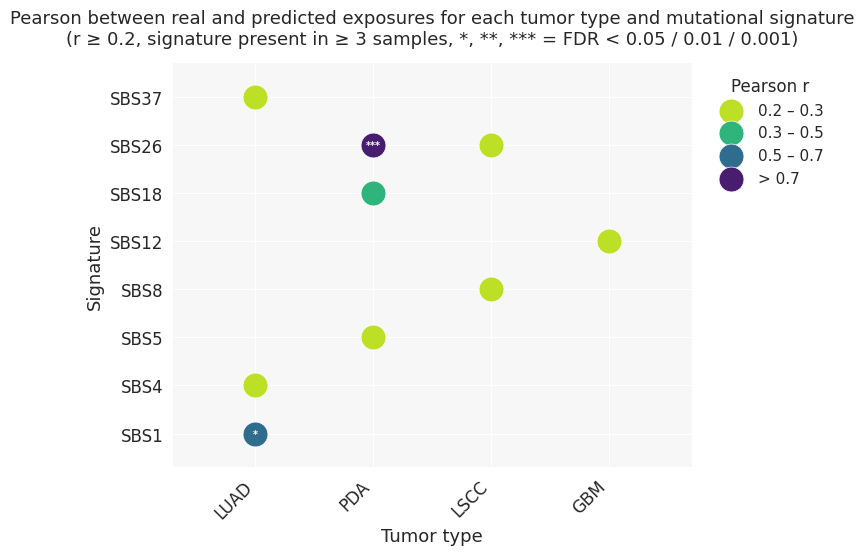

In [17]:
pearson_cptac = se.plot_pearson_bubble_cptac(
    true_activities_cptac_gat, pred_cptac_gat_eval, proj_cptac)

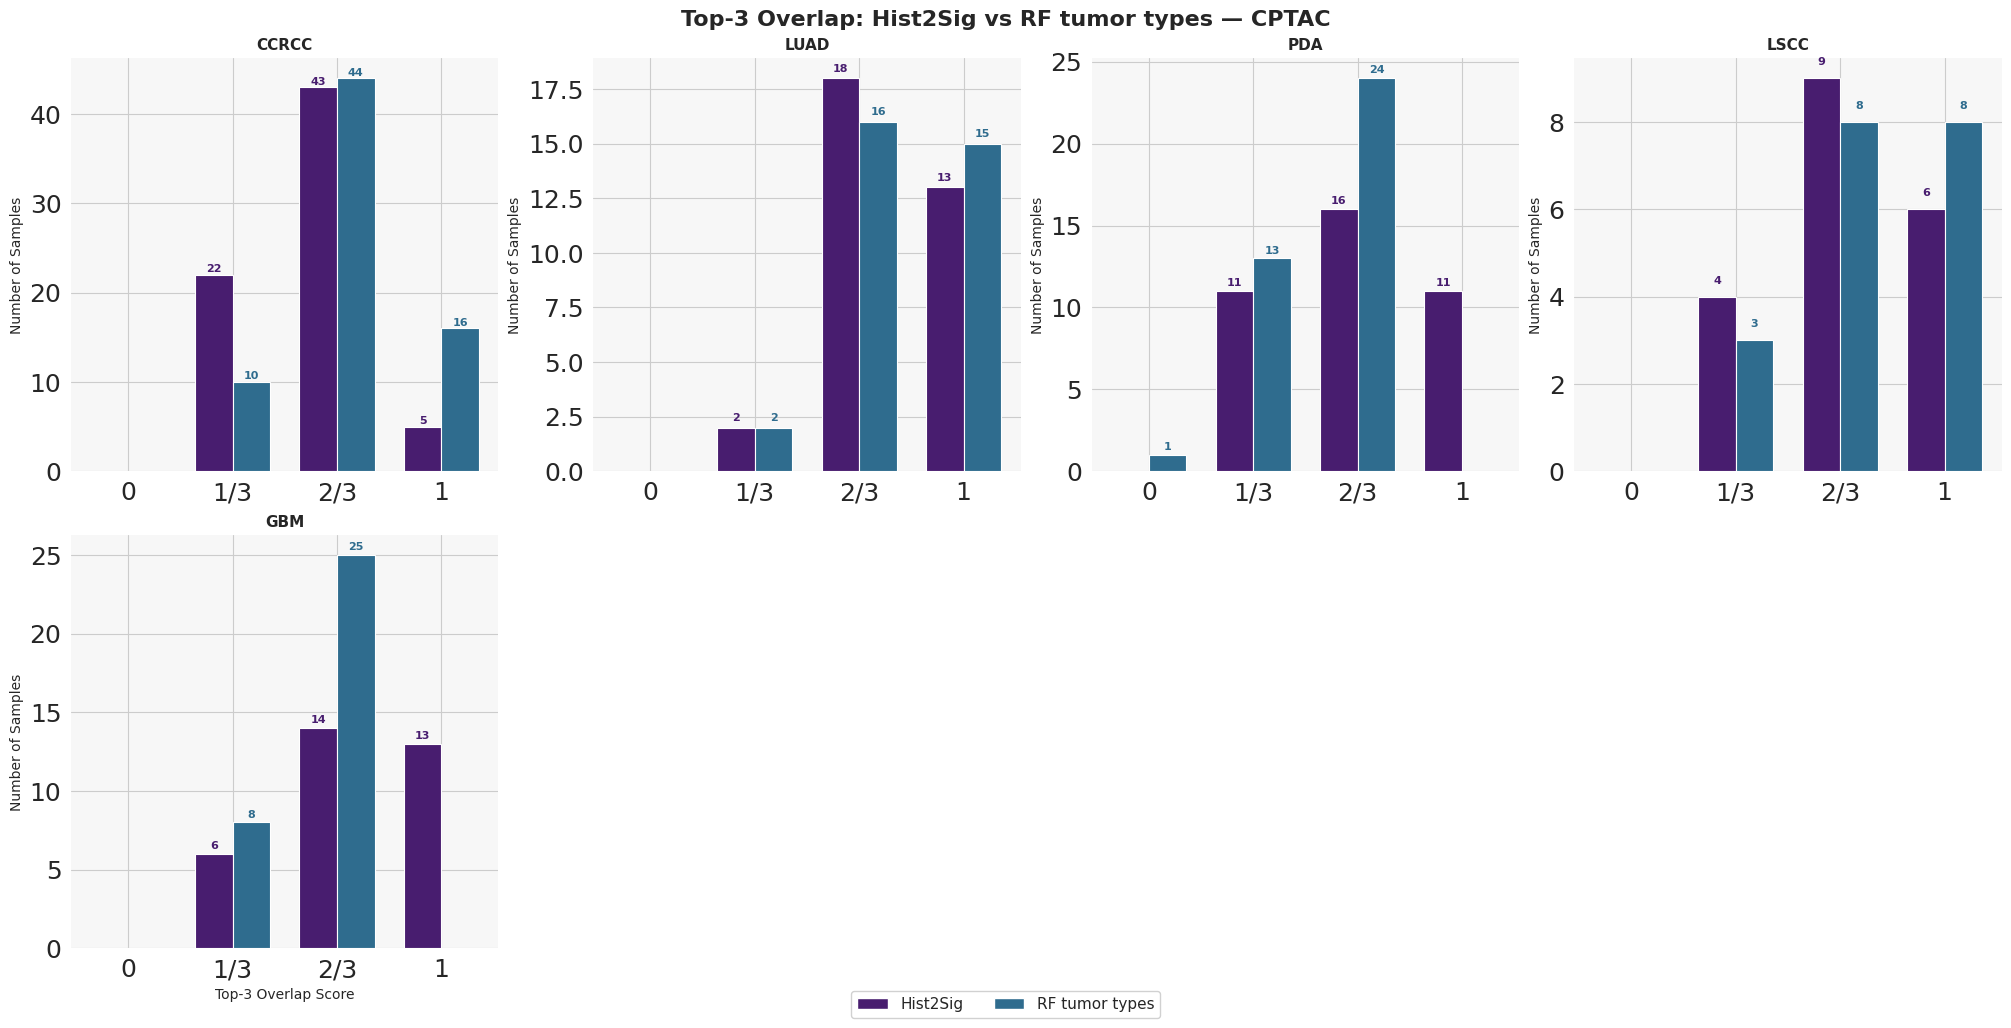

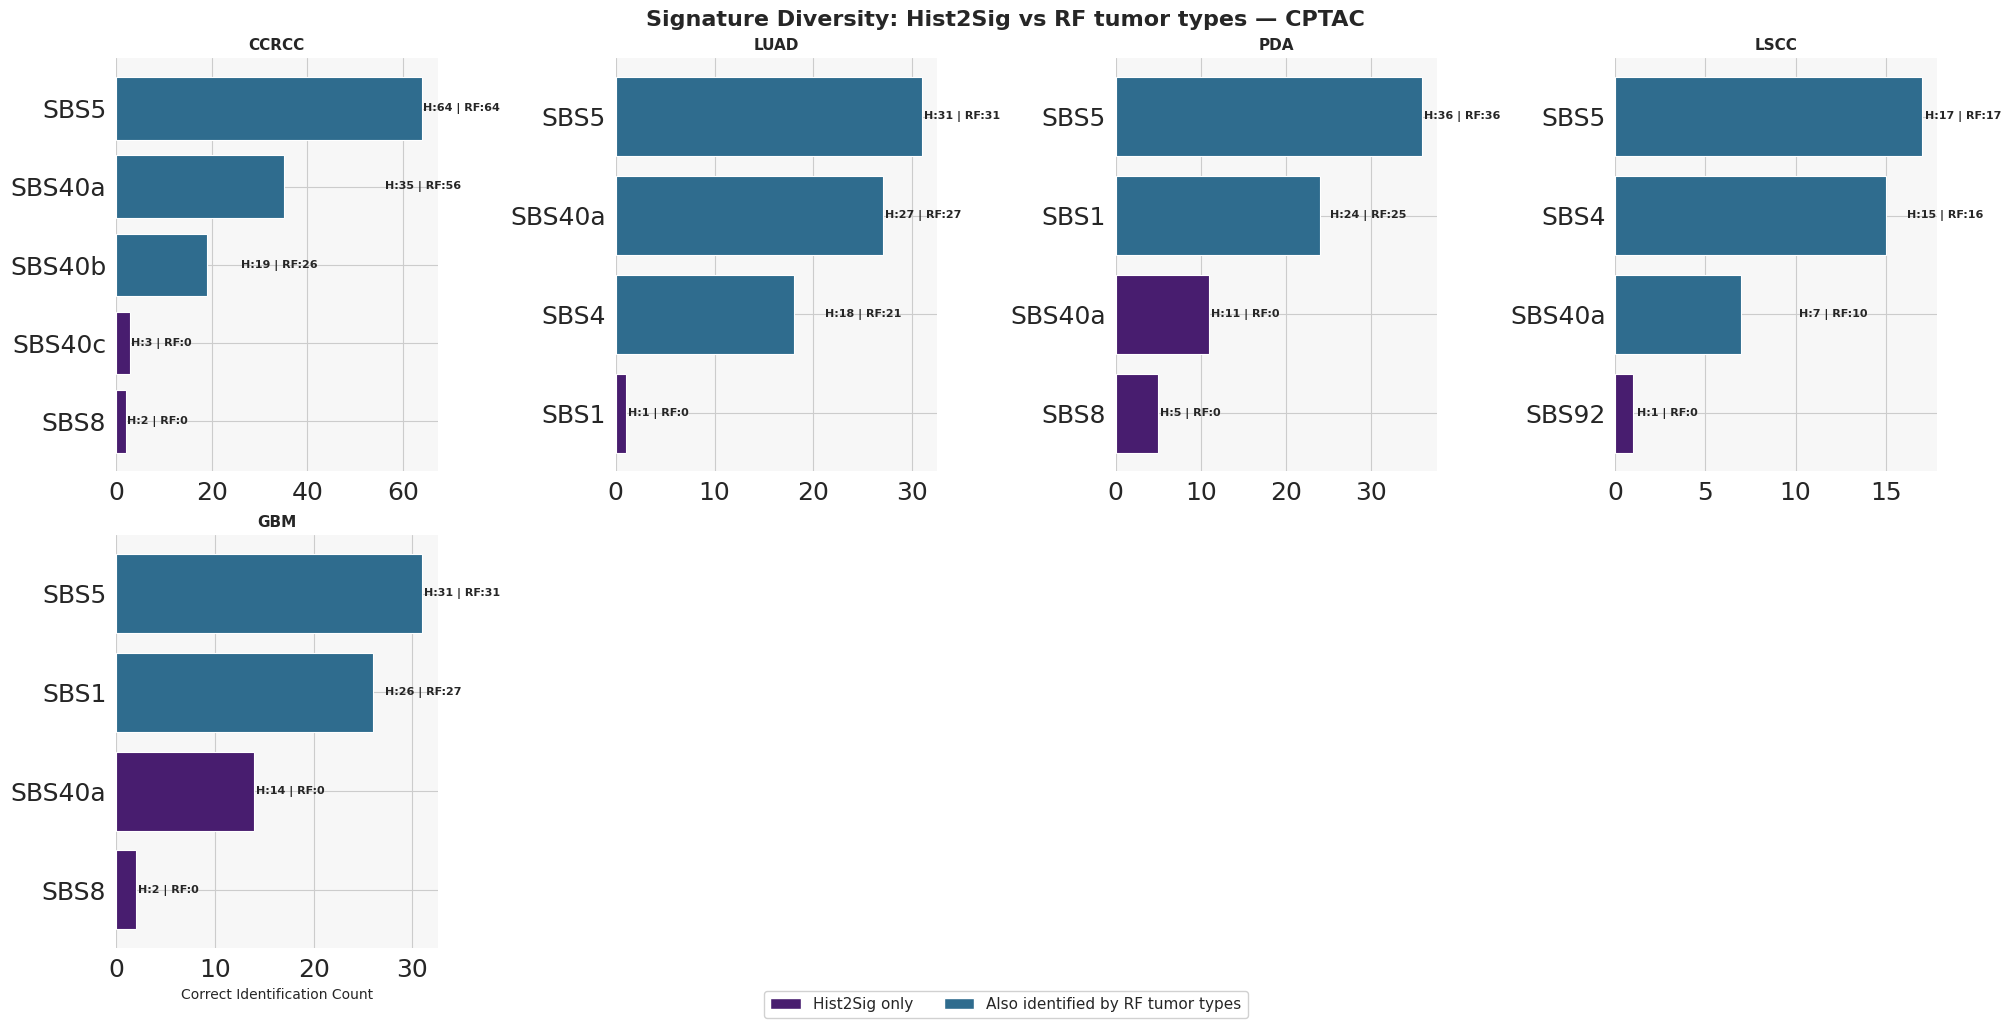

In [18]:
cptac = se.top3_figures_cptac(
    true_activities_cptac_gat, pred_cptac_gat_eval,
    final_model, X_cptac, y_cols, save_dir=save_dir)

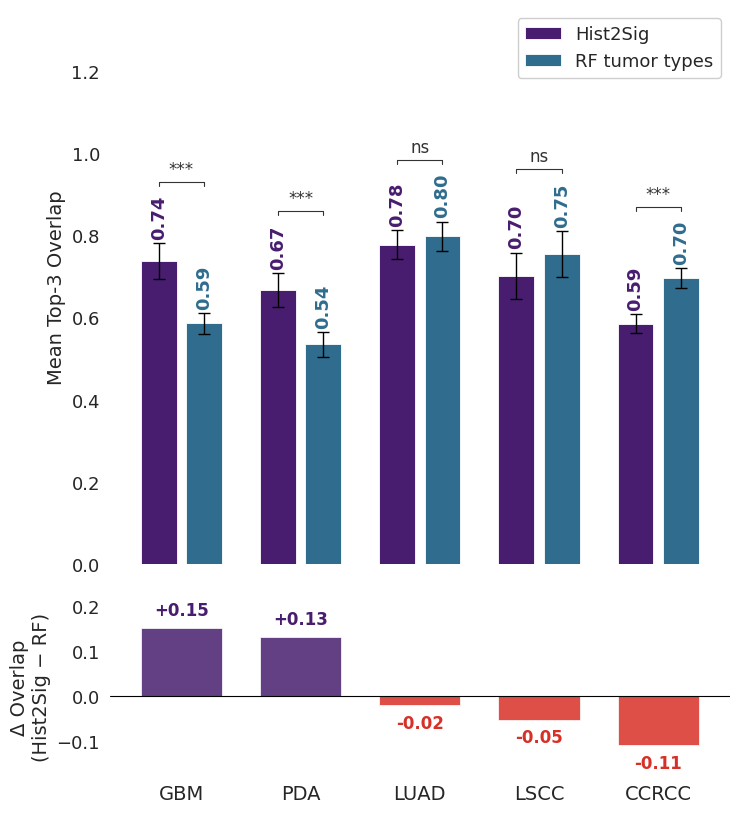

In [19]:
overlap_cptac = se.plot_mean_overlap_cptac(
    cptac["nn_true"], cptac["nn_pred"], cptac["rf_pred"],
    cptac["projects"], cptac["unique_projects"])

## Signature diversity, GBM and PAAD only

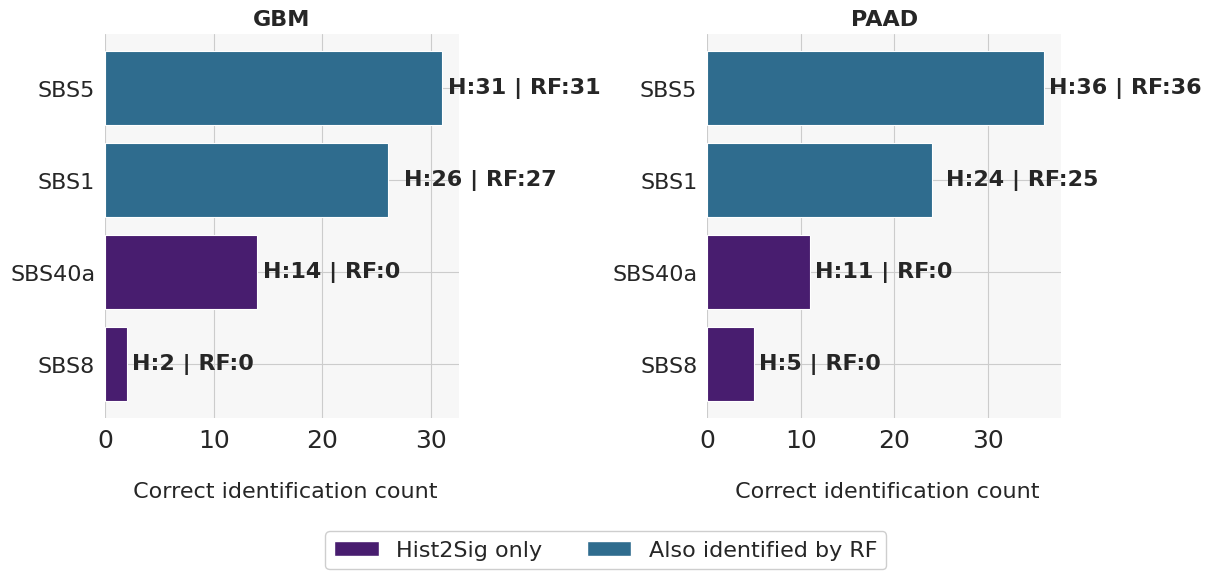

In [20]:
se.plot_signature_diversity_subset(
    cptac["all_nn_correct"], cptac["all_rf_correct"],
    selected=['TCGA-GBM', 'TCGA-PAAD'],
    short={'TCGA-GBM': 'GBM', 'TCGA-PAAD': 'PAAD'},
    save_path=f"{save_dir}/signature_diversity_CPTAC_GBM_PAAD.pdf")